## STEP 1 — VAE FREEZING

This step ensures that the previously trained VAE's encoder and decoder weights are frozen and the model is set to evaluation mode, preventing any updates to its parameters during the MLP training.

In [ ]:
# Freeze VAE parameters (encoder and decoder)
for param in vae.parameters():
    param.requires_grad = False

vae.eval() # Set VAE to evaluation mode
print("VAE parameters frozen and set to eval mode.")

VAE parameters frozen and set to eval mode.


## STEP 2 — ROTATION PAIRS DATASET

This step creates a PyTorch Dataset and DataLoader to provide `(z_theta, z_theta_plus_30)` pairs for training the Rotation MLP. It leverages the `latents_data` already loaded in memory to find corresponding latent vectors for a 30-degree rotation of the same original image.

In [ ]:
print("Building rotation pairs from in-memory latent data...")

# There are num_original_images unique original images, each rotated num_rotations_per_image times.
# num_original_images and num_rotations_per_image are available from previous execution if `cell 08c44c69` was run.
# If not, let's re-calculate them from the in-memory data.
# Assuming all_z, all_angles, all_labels, all_original_images_tensor are in memory from Notebook 1's `cell 38e1caff`

# Create a dictionary to quickly look up z for a given original_image_idx and angle
z_lookup = {}
num_unique_angles = len(np.unique(all_angles))

# Reconstruct original image indices based on how `RotatedMNISTDataset` was constructed.
# The indices `i` directly correspond to (original_image_idx * num_rotations_per_image + rotation_idx)
# So, original_img_idx = i // num_rotations_per_image

for i in range(len(all_z)):
    original_img_idx_from_flat_idx = i // num_unique_angles
    angle = int(all_angles[i])
    # Store (z_vector, label) associated with (original_img_idx, angle)
    z_lookup[(original_img_idx_from_flat_idx, angle)] = {'z': all_z[i], 'label': all_labels[i], 'mu': all_mu[i]}

rotation_pairs = []

for i in tqdm(range(len(all_z)), desc="Collecting rotation pairs"):
    original_img_idx = i // num_unique_angles
    current_angle = int(all_angles[i])
    current_z = all_z[i]
    current_mu = all_mu[i]
    current_label = all_labels[i]

    # Calculate the target angle for a 30-degree rotation
    target_angle = (current_angle + 30) % 360

    # Look up the corresponding z for the target angle and same original image
    target_key = (original_img_idx, target_angle)

    if target_key in z_lookup:
        z_rotated_30 = z_lookup[target_key]['z']
        mu_rotated_30 = z_lookup[target_key]['mu']
        label_rotated_30 = z_lookup[target_key]['label']

        # Ensure that the label is consistent for the same original image
        if current_label != label_rotated_30:
            print(f"Warning: Mismatched labels for original image {original_img_idx} at angles {current_angle} and {target_angle}. Skipping this pair.")
            continue

        rotation_pairs.append({
            'z_original': torch.tensor(current_z, dtype=torch.float32),
            'mu_original': torch.tensor(current_mu, dtype=torch.float32),
            'angle_original': torch.tensor(current_angle, dtype=torch.float32),
            'z_rotated_30_ground_truth': torch.tensor(z_rotated_30, dtype=torch.float32),
            'mu_rotated_30_ground_truth': torch.tensor(mu_rotated_30, dtype=torch.float32),
            'angle_rotated_30_ground_truth': torch.tensor(target_angle, dtype=torch.float32),
            'label': torch.tensor(current_label, dtype=torch.long),
            'original_image_idx': torch.tensor(original_img_idx, dtype=torch.long)
        })

print(f"Total number of rotation pairs created: {len(rotation_pairs)}")

# Create a PyTorch Dataset and DataLoader for these rotation pairs
class RotationPairsDataset(Dataset):
    def __init__(self, rotation_pairs_list):
        self.rotation_pairs_list = rotation_pairs_list

    def __len__(self):
        return len(self.rotation_pairs_list)

    def __getitem__(self, idx):
        return self.rotation_pairs_list[idx]

rotation_dataset = RotationPairsDataset(rotation_pairs)
rotation_dataloader = DataLoader(rotation_dataset, batch_size=128, shuffle=True, drop_last=True)

print(f"Rotation Pairs Dataset size: {len(rotation_dataset)}")
print(f"Rotation Pairs DataLoader batches: {len(rotation_dataloader)}")

Building rotation pairs from in-memory latent data...


Total number of rotation pairs created: 106332
Rotation Pairs Dataset size: 106332
Rotation Pairs DataLoader batches: 830


## STEP 3 — ROTATION MLP ($T_\theta$)

This step defines the Multi-Layer Perceptron (MLP) architecture, its training setup including a custom loss function (latent space MSE + image space MSE), and then trains the MLP to learn the 30-degree rotation in the VAE's latent space.

In [ ]:
class RotationMLP(nn.Module):
    def __init__(self, latent_dim=32):
        super(RotationMLP, self).__init__()
        self.fc1 = nn.Linear(latent_dim, 128)
        self.ln1 = nn.LayerNorm(128)
        self.fc2 = nn.Linear(128, 128)
        self.ln2 = nn.LayerNorm(128)
        self.fc3 = nn.Linear(128, latent_dim)

    def forward(self, z):
        x = self.fc1(z)
        x = F.relu(self.ln1(x))
        x = self.fc2(x)
        x = F.relu(self.ln2(x))
        x = self.fc3(x)
        return x

# Instantiate the RotationMLP and move to device
rotation_mlp = RotationMLP(latent_dim=32).to(device)
print(rotation_mlp)

RotationMLP(
  (fc1): Linear(in_features=32, out_features=128, bias=True)
  (ln1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
  (fc2): Linear(in_features=128, out_features=128, bias=True)
  (ln2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
  (fc3): Linear(in_features=128, out_features=32, bias=True)
)


Starting Rotation MLP training...


Epoch 1/50:   0%|          | 0/830 [00:00<?, ?it/s]

Epoch [1/50], Loss: 22.8715


Epoch 2/50:   0%|          | 0/830 [00:00<?, ?it/s]

Epoch [2/50], Loss: 21.0218


...

Epoch [48/50], Loss: 19.9786


Epoch 49/50:   0%|          | 0/830 [00:00<?, ?it/s]

Epoch [49/50], Loss: 19.9780


Epoch 50/50:   0%|          | 0/830 [00:00<?, ?it/s]

Epoch [50/50], Loss: 19.9732
Rotation MLP training complete.


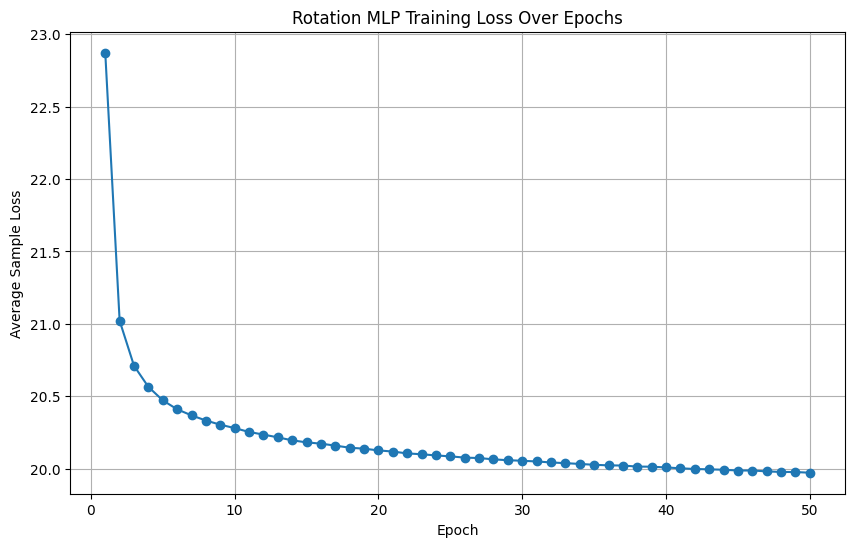

In [ ]:
# Loss function: MSE in latent space + MSE in image space (weighted)
# Optimizer: Adam
# Training for 50 epochs

optimizer_mlp = optim.Adam(rotation_mlp.parameters(), lr=1e-3)

# Training parameters
epochs_mlp = 50
training_losses_mlp = []

print("Starting Rotation MLP training...")
for epoch in range(epochs_mlp):
    rotation_mlp.train() # Set MLP to training mode
    epoch_loss_mlp = 0
    for batch_data in tqdm(rotation_dataloader, desc=f"Epoch {epoch+1}/{epochs_mlp}"):
        z_original = batch_data['z_original'].to(device)
        z_rotated_30_ground_truth = batch_data['z_rotated_30_ground_truth'].to(device)

        optimizer_mlp.zero_grad()

        # 1. Predict rotated latent vector
        z_rotated_predicted = rotation_mlp(z_original)

        # 2. Latent space MSE loss
        latent_mse_loss = F.mse_loss(z_rotated_predicted, z_rotated_30_ground_truth, reduction='sum')

        # 3. Image space MSE loss (decode and compare images)
        with torch.no_grad(): # Ensure VAE weights are not updated
            # original_decoded_img = vae.decode(z_original) # Not strictly needed for loss calculation
            ground_truth_rotated_decoded_img = vae.decode(z_rotated_30_ground_truth)

        predicted_rotated_decoded_img = vae.decode(z_rotated_predicted)

        # Use a small beta for image space loss as it's typically larger in magnitude
        image_mse_loss = F.mse_loss(predicted_rotated_decoded_img, ground_truth_rotated_decoded_img, reduction='sum')

        # Total Loss
        # As specified: Loss = MSE(T_theta(z), z_rotated) + 0.1 * MSE(decoder(T_theta(z)), decoder(z_rotated))
        total_loss = latent_mse_loss + 0.1 * image_mse_loss

        total_loss.backward()
        optimizer_mlp.step()

        epoch_loss_mlp += total_loss.item()

    avg_epoch_loss_mlp = epoch_loss_mlp / len(rotation_dataset) # Average loss per sample
    training_losses_mlp.append(avg_epoch_loss_mlp)
    print(f"Epoch [{epoch+1}/{epochs_mlp}], Loss: {avg_epoch_loss_mlp:.4f}")

print("Rotation MLP training complete.")

# Plot training curve
plt.figure(figsize=(10, 6))
plt.plot(range(1, epochs_mlp + 1), training_losses_mlp, marker='o')
plt.title('Rotation MLP Training Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Average Sample Loss')
plt.grid(True)
plt.show()

## STEP 4 — VERIFY ROTATION CHAIN

To confirm $T_\theta$ has learned a true 30° rotation:
- Pick 5 test images
- Apply $T_\theta$ repeatedly 12 times (0° → 30° → ... → 330° → back to 0°)
- Decode each step and display as a horizontal strip of 12 images
- The last decoded image should visually resemble the original (360° = identity)

Verifying rotation chain...


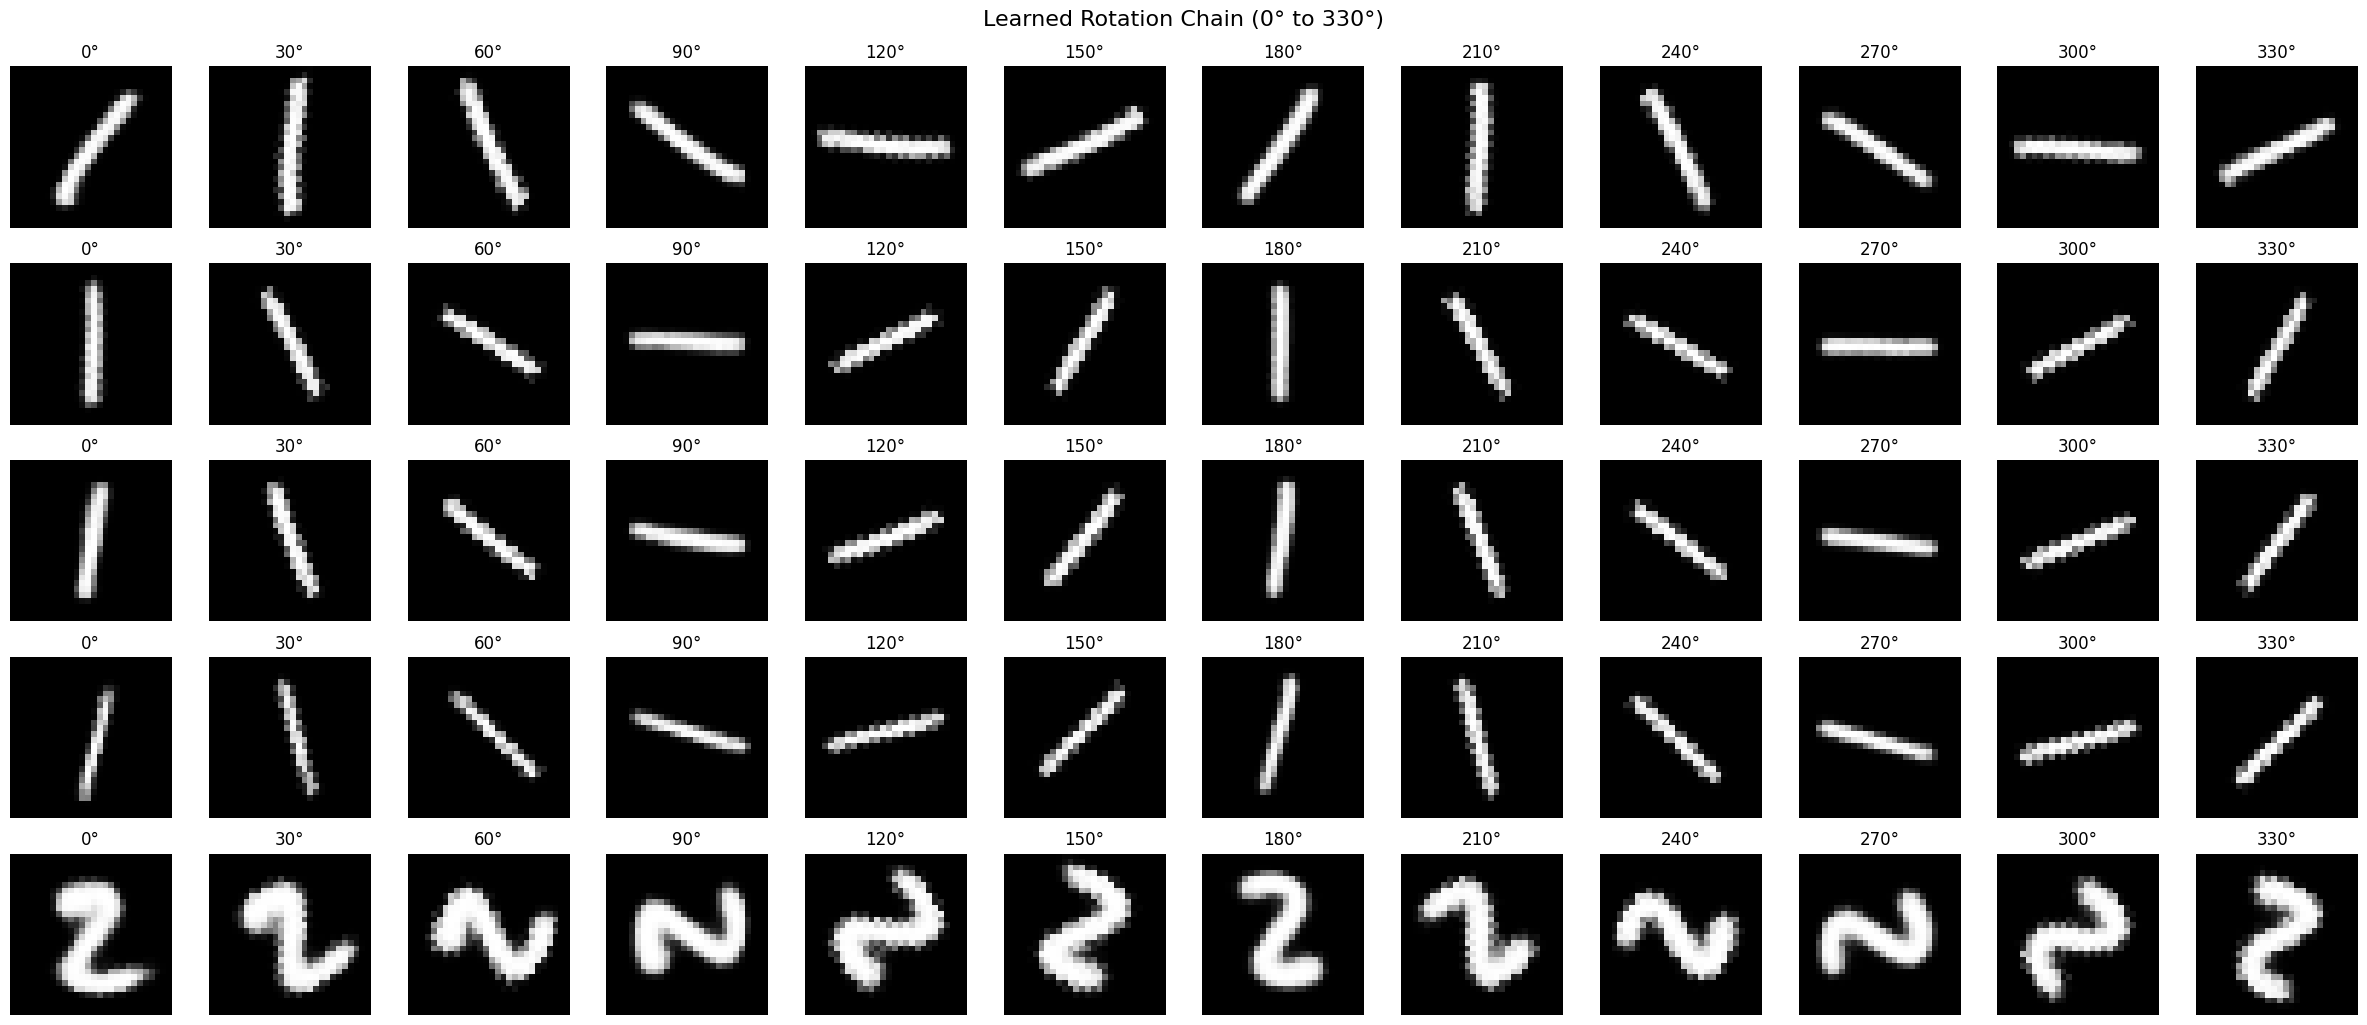

In [ ]:
rotation_mlp.eval() # Set MLP to evaluation mode
vae.eval() # Ensure VAE is in evaluation mode

print("Verifying rotation chain...")

# Get a few sample original image indices for testing. We need 'original_img_idx' for z_lookup.
# Sample from the unique original image indices available in z_lookup (keys are (original_img_idx, angle))
# We'll take the first 5 unique original_img_idx found in z_lookup
sample_original_img_indices = []
seen_indices = set()
for original_img_idx, _ in z_lookup.keys():
    if original_img_idx not in seen_indices:
        sample_original_img_indices.append(original_img_idx)
        seen_indices.add(original_img_idx)
    if len(sample_original_img_indices) == 5:
        break

if len(sample_original_img_indices) < 5:
    print(f"Warning: Could only find {len(sample_original_img_indices)} unique original images for verification.")

num_rotations_per_image = len(np.unique(all_angles)) # This should be 12

fig, axes = plt.subplots(len(sample_original_img_indices), num_rotations_per_image, figsize=(2 * num_rotations_per_image, 2 * len(sample_original_img_indices)))

for i, original_img_idx in enumerate(sample_original_img_indices):
    # Find the z for 0-degree rotation of this original image
    initial_z_key = (original_img_idx, 0) # Assuming 0-degree is always available
    if initial_z_key not in z_lookup:
        print(f"Warning: 0-degree rotation not found for original image index {original_img_idx}. Skipping.")
        continue

    # unsqueeze(0) to add a batch dimension of 1
    current_z = torch.tensor(z_lookup[initial_z_key]['z'], dtype=torch.float32).to(device).unsqueeze(0)

    for j in range(num_rotations_per_image): # 12 rotations (0, 30, ..., 330)
        with torch.no_grad():
            decoded_image = vae.decode(current_z)

        ax = axes[i, j]
        ax.imshow(decoded_image.squeeze().cpu().numpy(), cmap='gray')
        ax.set_title(f"{j*30}°")
        ax.axis('off')

        # Apply the learned rotation operator for the next step
        current_z = rotation_mlp(current_z)

plt.tight_layout()
plt.suptitle("Learned Rotation Chain (0° to 330°)", y=1.02, fontsize=16)
plt.show()

## STEP 5 — VISUALIZATION & METRICS

This step visualizes the predicted 30-degree rotation against the true 30-degree rotation for two sample digits (one '1' and one '2' at 0°). It also calculates the Image Mean Squared Error (MSE) between the predicted and true decoded images to quantify the performance of the Rotation MLP.

Visualizing predicted vs. true 30-degree rotations and calculating metrics...


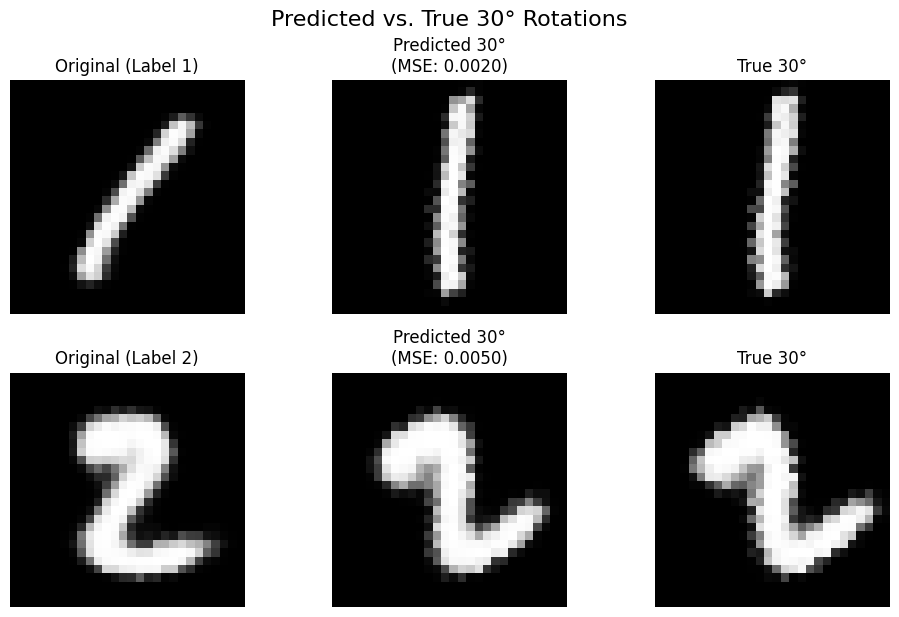

In [ ]:
rotation_mlp.eval()
vae.eval()

print("Visualizing predicted vs. true 30-degree rotations and calculating metrics...")

# Find a sample '1' and a sample '2' at 0 degrees
# Filter for 0-degree rotations
zero_degree_samples = [(idx, angle) for idx, angle in z_lookup.keys() if angle == 0]

sample_1_found = False
sample_2_found = False

sample_1_idx = None
sample_2_idx = None

for original_img_idx, angle in zero_degree_samples:
    label = z_lookup[(original_img_idx, angle)]['label']
    if label == 1 and not sample_1_found:
        sample_1_idx = original_img_idx
        sample_1_found = True
    elif label == 2 and not sample_2_found:
        sample_2_idx = original_img_idx
        sample_2_found = True
    if sample_1_found and sample_2_found:
        break

sample_indices_for_viz = []
if sample_1_idx is not None: sample_indices_for_viz.append((sample_1_idx, 1))
if sample_2_idx is not None: sample_indices_for_viz.append((sample_2_idx, 2))

if not sample_indices_for_viz:
    print("Could not find sample images for visualization (digits 1 and 2 at 0 degrees).")
else:
    fig, axes = plt.subplots(len(sample_indices_for_viz), 3, figsize=(10, len(sample_indices_for_viz) * 3))
    if len(sample_indices_for_viz) == 1: axes = [axes] # Handle single row case

    for i, (original_img_idx, label_val) in enumerate(sample_indices_for_viz):
        z_0_deg = torch.tensor(z_lookup[(original_img_idx, 0)]['z'], dtype=torch.float32).to(device).unsqueeze(0)
        z_30_deg_true = torch.tensor(z_lookup[(original_img_idx, 30)]['z'], dtype=torch.float32).to(device).unsqueeze(0)

        with torch.no_grad():
            decoded_original = vae.decode(z_0_deg)
            z_30_deg_predicted = rotation_mlp(z_0_deg)
            decoded_predicted_30 = vae.decode(z_30_deg_predicted)
            decoded_true_30 = vae.decode(z_30_deg_true)

            # Calculate Image MSE
            image_mse = F.mse_loss(decoded_predicted_30, decoded_true_30, reduction='mean').item()

        # Plot Original
        axes[i, 0].imshow(decoded_original.squeeze().cpu().numpy(), cmap='gray')
        axes[i, 0].set_title(f"Original (Label {label_val})")
        axes[i, 0].axis('off')

        # Plot Predicted 30°
        axes[i, 1].imshow(decoded_predicted_30.squeeze().cpu().numpy(), cmap='gray')
        axes[i, 1].set_title(f"Predicted 30°\n(MSE: {image_mse:.4f})")
        axes[i, 1].axis('off')

        # Plot True 30°
        axes[i, 2].imshow(decoded_true_30.squeeze().cpu().numpy(), cmap='gray')
        axes[i, 2].set_title("True 30°")
        axes[i, 2].axis('off')

    plt.tight_layout()
    plt.suptitle("Predicted vs. True 30° Rotations", y=1.02, fontsize=16)
    plt.show()

## STEP 6 — EXPORT

This final step saves the trained Rotation MLP weights to Google Drive, allowing it to be reused or integrated into other parts of the project.

In [ ]:
# Define the save path (same directory as VAE weights)
save_path_mlp = '/content/drive/MyDrive/gsoc_symmetry/'

# Create the directory if it doesn't exist
os.makedirs(save_path_mlp, exist_ok=True)

model_save_path_mlp = os.path.join(save_path_mlp, 'rotation_mlp.pth')
torch.save(rotation_mlp.state_dict(), model_save_path_mlp)
print(f"Trained Rotation MLP model saved to: {model_save_path_mlp}")

Trained Rotation MLP model saved to: /content/drive/MyDrive/gsoc_symmetry/rotation_mlp.pth
